In [11]:
!pip install nltk PyPDF2 wordcloud scikit-learn

import nltk
nltk.download('punkt_tab')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/shrikargopinath/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [12]:
import pandas as pd
import re
import nltk

from nltk.tokenize import sent_tokenize
from PyPDF2 import PdfReader

nltk.download('punkt')

reader = PdfReader("Python Essay Dataset.pdf")

text = ""

for page in reader.pages:
    
    page_text = page.extract_text()
    
    if page_text:
        text += page_text + " "

text = re.sub(r'\s+', ' ', text)

sentences = sent_tokenize(text)

clean_sentences = []

for s in sentences:
    
    s = s.strip()
    
    if len(s) > 20:
        clean_sentences.append(s)

df = pd.DataFrame(clean_sentences, columns=["sentence"])

df.to_csv("writing_dataset.csv", index=False)

print(df.head())

print(df.shape)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/shrikargopinath/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                            sentence
0  “Redeplo ymen t”: The Paradox of Expanding Hum...
1  Not by acciden t. We did it on purpose” (Klay 1).
2  The brut ality depict ed in this scene at firs...
3  Arriving at a familiar stream, Price prepar es...
4  At a surface level, these two momen ts look va...
(594, 1)


In [13]:
df["clean_text"] = df["sentence"].str.lower()

print(df[["sentence", "clean_text"]].head())

                                            sentence  \
0  “Redeplo ymen t”: The Paradox of Expanding Hum...   
1  Not by acciden t. We did it on purpose” (Klay 1).   
2  The brut ality depict ed in this scene at firs...   
3  Arriving at a familiar stream, Price prepar es...   
4  At a surface level, these two momen ts look va...   

                                          clean_text  
0  “redeplo ymen t”: the paradox of expanding hum...  
1  not by acciden t. we did it on purpose” (klay 1).  
2  the brut ality depict ed in this scene at firs...  
3  arriving at a familiar stream, price prepar es...  
4  at a surface level, these two momen ts look va...  


In [14]:
df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

print(df["sentence"].iloc[0])

print(df["clean_text"].iloc[0])

“Redeplo ymen t”: The Paradox of Expanding Humanity Through Repression By Shrik ar Gopina th Phil Klay's “Redeplo ymen t” opens with Sergeant Price’ s unse ttling confession: “We shot dogs.
redeplo ymen t the paradox of expanding humanity through repression by shrik ar gopina th phil klays redeplo ymen t opens with sergeant price s unse ttling confession we shot dogs


In [15]:
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

df["tokens"] = df["clean_text"].apply(word_tokenize)

print(df["tokens"].head())

0    [redeplo, ymen, t, the, paradox, of, expanding...
1    [not, by, acciden, t, we, did, it, on, purpose...
2    [the, brut, ality, depict, ed, in, this, scene...
3    [arriving, at, a, familiar, stream, price, pre...
4    [at, a, surface, level, these, two, momen, ts,...
Name: tokens, dtype: object


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/shrikargopinath/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/shrikargopinath/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [16]:
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words("english"))

df["tokens_no_stop"] = df["tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

print(df["tokens_no_stop"].head())

0    [redeplo, ymen, paradox, expanding, humanity, ...
1                             [acciden, purpose, klay]
2    [brut, ality, depict, ed, scene, first, seems,...
3    [arriving, familiar, stream, price, prepar, es...
4    [surface, level, two, momen, ts, look, vastly,...
Name: tokens_no_stop, dtype: object


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shrikargopinath/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
documents = []

for i in range(0, len(df), 10):
    
    chunk = df["tokens_no_stop"].iloc[i:i+10]
    
    combined = []
    
    for sentence_tokens in chunk:
        combined.extend(sentence_tokens)
    
    documents.append(" ".join(combined))

documents_df = pd.DataFrame(documents, columns=["document"])

print(documents_df.head())

print(documents_df.shape)

                                            document
0  redeplo ymen paradox expanding humanity repres...
1  hes shown emphasizing first time shoots dog in...
2  controls breathing fires precise triple shot r...
3  detachmen signal emotional emp tiness rather r...
4  hit ball almost perfectly itll die without sli...
(60, 1)


In [18]:
documents = []

for i in range(0, len(df), 10):
    ten_sentences = df["tokens_no_stop"].iloc[i:i+10]
    
    document_words = []
    
    for token_list in ten_sentences:
        for word in token_list:
            document_words.append(word)
    
    documents.append(" ".join(document_words))

documents_df = pd.DataFrame(documents, columns=["document"])

print(documents_df.head())
print(documents_df.shape)

                                            document
0  redeplo ymen paradox expanding humanity repres...
1  hes shown emphasizing first time shoots dog in...
2  controls breathing fires precise triple shot r...
3  detachmen signal emotional emp tiness rather r...
4  hit ball almost perfectly itll die without sli...
(60, 1)


In [19]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

bow_matrix = count_vectorizer.fit_transform(documents_df["document"])

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=count_vectorizer.get_feature_names_out()
)

print(bow_df.head())
print(bow_df.shape)

   abandon  abandoning  abcclio  abide  ability  able  ably  absence  accept  \
0        0           1        0      0        1     1     0        0       0   
1        0           0        0      0        0     1     0        0       0   
2        0           0        0      0        1     1     0        1       0   
3        0           0        0      0        0     0     1        0       0   
4        0           0        0      0        0     0     0        0       0   

   accepted  ...  yl  ymen  york  young  younger  youre  ys  zebr  zero  zoo  
0         0  ...   0     2     0      0        0      0   0     0     0    0  
1         0  ...   1     0     0      0        0      0   0     0     0    0  
2         0  ...   0     1     0      0        0      0   0     0     0    0  
3         0  ...   0     0     0      0        0      0   0     0     0    0  
4         0  ...   0     0     0      0        0      0   0     0     0    0  

[5 rows x 2461 columns]
(60, 2461)


each row represents a doc made up of ten sentences while each column represents a word. Each value shows how many times that word appears in said document. 

In [20]:
word_counts = bow_df.sum().sort_values(ascending=False)

top_20_words = word_counts.head(20)

print(top_20_words)

even         41
like         37
prospero     34
one          27
time         25
would        25
world        24
oedipus      22
act          22
power        22
though       21
essay        21
price        20
shot         20
true         19
king         19
nick         18
first        18
people       18
something    18
dtype: int64


The words with the highest total counts for my writing sample includes even, like, and essay which all make sense since they're connecting words and the word "essay" which is certainly used in every essay in the dataset. 

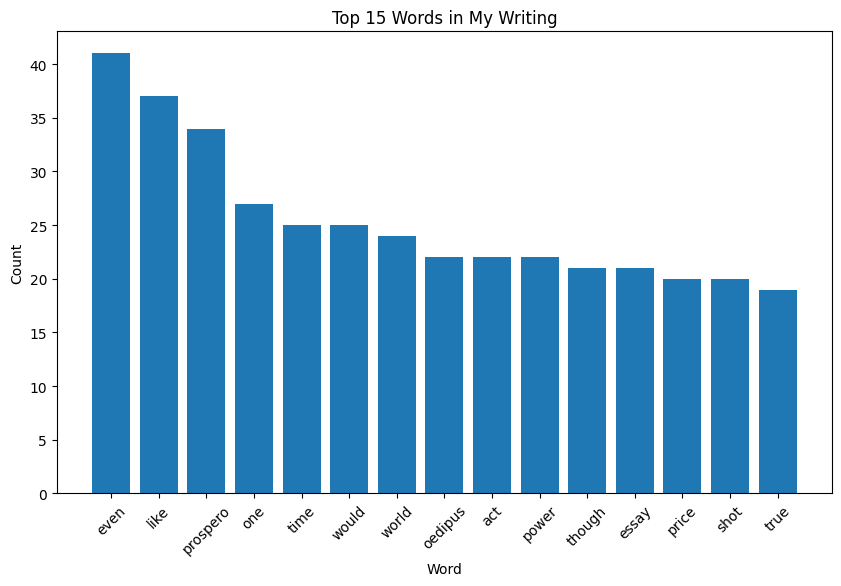

In [22]:
import matplotlib.pyplot as plt

top_15_words = word_counts.head(15)

plt.figure(figsize=(10,6))
plt.bar(top_15_words.index, top_15_words.values)
plt.xticks(rotation=45)
plt.title("Top 15 Words in My Writing")
plt.xlabel("Word")
plt.ylabel("Count")
plt.show()

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(documents_df["document"])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print(tfidf_df.head())
print(tfidf_df.shape)

   abandon  abandoning  abcclio  abide   ability      able      ably  \
0      0.0    0.084283      0.0    0.0  0.057835  0.071059  0.000000   
1      0.0    0.000000      0.0    0.0  0.000000  0.064147  0.000000   
2      0.0    0.000000      0.0    0.0  0.046213  0.056779  0.000000   
3      0.0    0.000000      0.0    0.0  0.000000  0.000000  0.105355   
4      0.0    0.000000      0.0    0.0  0.000000  0.000000  0.000000   

    absence  accept  accepted  ...        yl      ymen  york  young  younger  \
0  0.000000     0.0       0.0  ...  0.000000  0.153095   0.0    0.0      0.0   
1  0.000000     0.0       0.0  ...  0.076084  0.000000   0.0    0.0      0.0   
2  0.067346     0.0       0.0  ...  0.000000  0.061165   0.0    0.0      0.0   
3  0.000000     0.0       0.0  ...  0.000000  0.000000   0.0    0.0      0.0   
4  0.000000     0.0       0.0  ...  0.000000  0.000000   0.0    0.0      0.0   

   youre   ys  zebr  zero  zoo  
0    0.0  0.0   0.0   0.0  0.0  
1    0.0  0.0   0.0 

TF-IDF is different from simple word counts since it gives more weight to words that are important in one document even if they aren't common across all the documents.

In [24]:
average_tfidf = tfidf_df.mean().sort_values(ascending=False)

top_tfidf_words = average_tfidf.head(20)

print(top_tfidf_words)

prospero     0.037163
even         0.029749
essay        0.027300
shot         0.026772
like         0.026291
oedipus      0.024548
nick         0.023430
world        0.022255
power        0.021801
writing      0.021705
one          0.021007
monkey       0.020555
price        0.019647
time         0.019469
act          0.019196
something    0.019061
moment       0.018788
would        0.018484
every        0.018475
king         0.018194
dtype: float64


The highest TF-IDF words in my dataset include “prospero,” “oedipus,” “power,” “world,” “writing,” and “monkey.” These words are more unique and meaningful because they represent important themes, and haracters in my writing that appear very strongly and concentrated in areas rather than common across every essay. 

In [ ]:
comparison_df = pd.DataFrame({
    "bow_count": word_counts,
    "average_tfidf": average_tfidf
}).fillna(0)

comparison_df = comparison_df.sort_values(by="bow_count", ascending=False)

print(comparison_df.head(20))

Bag of Words shows which words appear most frequently overall, while TF-IDF shows which words are more distinctive and meaningful as a whole. Some words appear somewhat often, but TF-IDF actually helps reveal words that are important to SPECIFIC parts of my essays.

In [ ]:
top_15_tfidf = average_tfidf.head(15)

plt.figure(figsize=(10,6))
plt.bar(top_15_tfidf.index, top_15_tfidf.values)
plt.xticks(rotation=45)
plt.title("Top 15 TF-IDF Words")
plt.xlabel("Word")
plt.ylabel("Average TF-IDF Score")
plt.show()

In [ ]:
from wordcloud import WordCloud

tfidf_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(average_tfidf.to_dict())

plt.figure(figsize=(12,6))
plt.imshow(tfidf_wordcloud)
plt.axis("off")
plt.title("TF-IDF Word Cloud")
plt.show()

My writing actually focuses more on large overall themes like identity, choice, humanity, morality etc etc. The repeated words throughout my essay are also very analytical because of this and specifially theme based since most of my essays are analytical, evaluative essays. 

WORKSHEET 11 STARTS HERE

In [ ]:
from sklearn.cluster import KMeans

inertia_values = []

k_values = range(1, 11)

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(tfidf_matrix)
    
    inertia_values.append(kmeans.inertia_)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    inertia_values,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")

plt.ylabel("Inertia")

plt.title("Elbow Method for Optimal K")

plt.show()

The elbow point is the best number of clusters because it's the point where adding more clusters stops significantly reducing inertia.

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(tfidf_matrix)

df["cluster"] = clusters

print(df[["sentence", "cluster"]].head(20))

In [ ]:
print(df["cluster"].value_counts())

The clusters group together sentences with similar vocabulary and themes. Different clusters are there to represent different topics and various styles of writing within my essays.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced_data = pca.fit_transform(
    tfidf_matrix.toarray()
)

plt.figure(figsize=(10,6))

plt.scatter(
    reduced_data[:,0],
    reduced_data[:,1],
    c=clusters
)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.title("PCA Visualization of Writing Clusters")

plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(tfidf_matrix)

print(similarity_matrix.shape)

In [ ]:
sentence_index = 0

similar_scores = list(
    enumerate(similarity_matrix[sentence_index])
)

similar_scores = sorted(
    similar_scores,
    key=lambda x: x[1],
    reverse=True
)

print("Original Sentence:\n")

print(df.iloc[sentence_index]["sentence"])

print("\nMost Similar Sentences:\n")

for i in similar_scores[1:6]:
    
    print(df.iloc[i[0]]["sentence"])
    
    print("Similarity Score:", i[1])
    
    print()

The clustering and similarity analysis showed that many of my writing samples naturally group around topics like identity, morality, and  struggles. Cosine similarity was very useful for identifying the sentences with similar vocabulary and meaning that were related to each other, while KMeans clustering was more helpful for visualizing how the different themes in my essays connect together.